# **Импорт библиотек**

In [ ]:
# Работа с массивами данных
import numpy as np

# Работа с таблицами
import pandas as pd

# Отрисовка графиков
import matplotlib.pyplot as plt

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation,GlobalMaxPooling1D

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Заполнение последовательностей до определенной длины
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Загрузка датасетов из облака google
import gdown
from tensorflow.keras.callbacks import EarlyStopping
# Для работы с файлами в Colaboratory
import os

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

# **Получение данных**

In [ ]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip', None, quiet=True)
# Распаковка архива в папку writers
!unzip -qo tesla.zip -d tesla/

# Просмотр содержимого папки
!ls tesla

'Негативный отзыв.txt'	'Позитивный отзыв.txt'


# **Функция для получения текста**

In [ ]:
# Объявляем функции для чтения файла. На вход отправляем путь к файлу
def read_text(file_name):

  # Задаем открытие нужного файла в режиме чтения
  read_file = open(file_name, 'r')

  # Читаем текст
  text = read_file.read()

  # Переносы строки переводим в пробелы
  text = text.replace("\n", " ")

  # Возвращаем текст файла
  return text

# Объявляем интересующие нас классы
class_names = ["Негативный отзыв", "Позитивный отзыв"]

# Считаем количество классов
num_classes = len(class_names)

# **Создание списка**

In [ ]:
import os
# Создаём список под тексты для обучающей выборки
texts_list = []

# Циклом проводим итерацию по текстовым файлам в папке отзывов
for j in os.listdir('/content/tesla/'):

  # Добавляем каждый файл в общий список для выборки
        texts_list.append(read_text('/content/tesla/' + j))

        # Выводим на экран сообщение о добавлении файла
        print(j, 'добавлен в обучающую выборку')

Негативный отзыв.txt добавлен в обучающую выборку
Позитивный отзыв.txt добавлен в обучающую выборку


# **Обработка текста**

In [ ]:
# Узнаем объём каждого текста в словах и символах
texts_len = [len(text) for text in texts_list]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Выводим на экран  информационное сообщение
print(f'Размеры текстов по порядку (в токенах):')

# Циклом проводим итерацию по списку с объёмами текстов
for text_len in texts_len:

  # Запускаем "счётчик" номера текста
  t_num += 1

  # Выводим на экран сообщение о номере и объёме текста
  print(f'Текст №{t_num}: {text_len}')

Размеры текстов по порядку (в токенах):
Текст №1: 134535
Текст №2: 213381


# **Делим данные**

In [ ]:
# Создаём список с вложенным циклом по длинам текстов, где i - 100% текста, i/5 - 20% текста
train_len_shares = [(i - round(i/5)) for i in texts_len]

# Устанавливаем "счётчик" номера текста
t_num = 0

# Циклом проводим итерацию по списку с объёмами текстов равными 80% от исходных
for train_len_share in train_len_shares:

  # Запускаем "счётчик" номера текста
  t_num += 1

  # Выводим на экран сообщение о номере и объёме текста в 80% от исходного
  print(f'Доля 80% от текста №{t_num}: {train_len_share} символов')

Доля 80% от текста №1: 107628 символов
Доля 80% от текста №2: 170705 символов


# **Нарезаем текст**

In [ ]:
from itertools import chain
# Ваше решение
# Создаем списки для обучающих и проверочных текстов
train_texts = []
val_texts = []

# Циклом нарезаем каждый текст на две части
for i in range(len(texts_list)):
    train_texts.append(texts_list[i][:train_len_shares[i]]) # 80% текста
    val_texts.append(texts_list[i][train_len_shares[i]:])  # Остальные 20%

print(f'Длина обучающего текста №1: {len(train_texts[0])} символов')
print(f'Длина проверочного текста №1: {len(val_texts[0])} символов')

Длина обучающего текста №1: 107628 символов
Длина проверочного текста №1: 26907 символов


# **Создаем гиперпараметры**

In [ ]:
# Задаем максимальное количество слов (самые частые)
max_words_count = 20000

# Инициализируем токенизатор
tokenizer = Tokenizer(num_words=max_words_count,
                      filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
                      lower=True,
                      split=' ',
                      oov_token='unknown')

# Обучаем токенизатор на обучающих текстах
tokenizer.fit_on_texts(train_texts)

# Преобразуем тексты в последовательности индексов
train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)

# **Образуем выборки**

In [ ]:
# Функция для создания выборок из последовательностей индексов
def get_samples(sequences, x_len, step):
    samples = []
    for seq in sequences:
        for i in range(0, len(seq) - x_len + 1, step):
            samples.append(seq[i:i + x_len])
    return np.array(samples)

# Параметры окна
x_len = 100  # Длина одного примера в словах

# Балансировка: подбираем шаг так, чтобы количество примеров было равным.
# Текст №1 (Позитив) длиннее, сделаем шаг больше. Текст №2 (Негатив) короче — шаг меньше.
x_train_0 = get_samples([train_sequences[0]], x_len, step=10) # Позитивные
x_train_1 = get_samples([train_sequences[1]], x_len, step=6)  # Негативные

# То же самое для проверочной выборки
x_val_0 = get_samples([val_sequences[0]], x_len, step=10)
x_val_1 = get_samples([val_sequences[1]], x_len, step=6)

print(f'Примеров в обучающей выборке: класс 0 — {len(x_train_0)}, класс 1 — {len(x_train_1)}')

# Объединяем классы и создаем метки ответов (y)
x_train = np.concatenate([x_train_0, x_train_1])
y_train = np.concatenate([np.zeros(len(x_train_0)), np.ones(len(x_train_1))])

x_val = np.concatenate([x_val_0, x_val_1])
y_val = np.concatenate([np.zeros(len(x_val_0)), np.ones(len(x_val_1))])

# Преобразуем метки в формат One Hot Encoding
y_train = utils.to_categorical(y_train, num_classes)
y_val = utils.to_categorical(y_val, num_classes)

Примеров в обучающей выборке: класс 0 — 1691, класс 1 — 4313


# **Создание и обучение модели**

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.6834 - loss: 0.6039 - val_accuracy: 0.7204 - val_loss: 0.5796
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9209 - loss: 0.2102 - val_accuracy: 0.7204 - val_loss: 0.5951
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9803 - loss: 0.0653 - val_accuracy: 0.7204 - val_loss: 0.6497
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9917 - loss: 0.0345 - val_accuracy: 0.7250 - val_loss: 0.6056
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9947 - loss: 0.0205 - val_accuracy: 0.7786 - val_loss: 0.4972
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9953 - loss: 0.0146 - val_accuracy: 0.8096 - val_loss: 0.5061
Epoch 7/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9972 - loss: 0.0109 - val_accuracy: 0.8268 - val_loss: 0.4884
Epoch 8/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9972 - loss: 0.0111 - val_accuracy: 0.8282 - val_loss

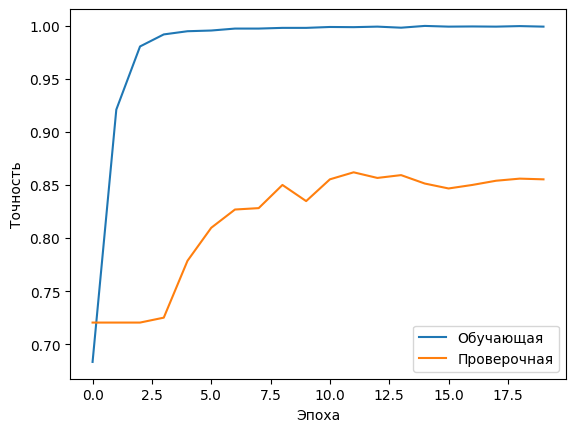

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',  # следим за ошибкой на валидации
    patience=8,          # ждем 5 эпох
    restore_best_weights=True  # возвращаем лучшие веса
)

# Создаем модель
model = Sequential()
model.add(Embedding(max_words_count, 100, input_length=x_len))
model.add(SpatialDropout1D(0.3))
model.add(GlobalMaxPooling1D())
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Компиляция
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Обучение
history = model.fit(x_train,
                    y_train,
                    epochs=30,
                    batch_size=64,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stop])

# Визуализация точности
plt.plot(history.history['accuracy'], label='Обучающая')
plt.plot(history.history['val_accuracy'], label='Проверочная')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()
plt.show()